# Investigate Changes in NAO Persistence in a Simulation with Intensifying ENSO


Investigate the following relationships between ENSO (Niño3.4 Index) and NAO in the 31km AWI-CM3 simulation, SSP5.85 Scenario.

I. 1-month NAO Persistence (All Months)

II. 1-month NAO Persistence (DJF Only)

III. 1-year NAO Persistence (DJF to DJF)

IV. Simultaneous ENSO-NAO Relationship (All Months *and* DJF Only)

Glenn Liu (gliu8@hawaii.edu); Last Updated 2026.07.02

In [1]:
import sys
import time
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import xarray as xr
import sys
import tqdm
import glob 
import scipy as sp
import cartopy.crs as ccrs
import matplotlib as mpl
from tqdm.notebook import tqdm

# Additional Functions

For ease of use, I have pasted the functions I used for this notebook directly below. For the most updated/development version of the functions code, see the following repositories linked below:

- `amv/proc.py`: https://github.com/glennliu265/amv/blob/master/proc.py 
- `ensobase/utils.py`: https://github.com/glennliu265/ensobase/blob/main/utils.py


In [60]:
# From proc -----------------
def xrcorr_leadlag(dsbase,dslag,basemonth,leadlags,seasonal=False,debug=False,cov=False,regression=False):
    
    """
    Calculate the lead-lag correlation separately where lag 0 is the [basemonth] for each month between [dsbase] and [dslag] along the <time> dimension.
    Currently supports doing seasonal correlations (3 month windows). Note that if the last lag month exceeds the last year, the base timeseries will be
    truncated accordingly just for that calculation (different DOF).
    
    Inputs:
        dsbase    : DataArray with dimension <time>, - Base variable @ monthly frequency (this variable leads for positive lag)
        dslag     : DataArray with dimension <time>, - Lagged variable @ monthly frequency (negative lag, this variable leads)
        basemonth : Int,                             - Base month for seasonal correlation (lag 0 is anomalies for this month)
        leadlags  : Array of Int,                    - Leads (negative values) and Lags (positive values) to compute correlation over
        seasonal  : Bool,                            - Set to <True> to use a 3-month window for a "seasonal" calculation (i.e. D --> NDJ)
        debug     : Bool,                            - Set to <True> for verbose messages for debugging
        cov       : Bool,                            - Set to <True> to compute covariance instead of correlation
        regression: Bool,                            - Set to <True> to do linear regression
    Outputs:
        ds_out    : DataSet,                         - lead lag correlations <corr> for each <lag>, and corresponding <month>, along with degrees of freedom <dofs>
        
    Created: 2026.02.11, test script: seasonal_radiation_enso_regressions.ipynb
    Note   : 2026.06.04 -- still might be an issue with this function for repeating lags (see seasonal_leadlag_SEP.ipynb)
    Update 2026.06.05   -- Added fix + support to long leads/lags. See debug_xrcorr_leadlag_seasonal.ipynb
    """
        
    # Define simple functions
    selmon  = lambda ds,mon : ds.sel(time=ds.time.dt.month.isin([mon]))
    selyear = lambda ds,mon,ystart,yend : ds.sel(time=slice("%04i-%02i-01" % (ystart,mon),"%04i-%02i-01" %(yend,mon)))
    
    # Extract Lead Lag
    leads = leadlags[leadlags<0]
    lags  = leadlags[leadlags>=0]
    if debug:
        print("Leads: %s" % (leads))
        print("Lags: %s" % (lags))
    
    # Get Year Information (full period)
    ds               = dsbase # Just Shorthand
    years            = ds.time.dt.year
    ystart           = years[0]
    yend             = years[-1]
    
    # Get Number of Lead and Lag Years
    yearmax_lead,yearmax_lag = get_year_span(basemonth,leadlags,seasonal)
    
    baseyears                = np.arange(ystart+yearmax_lead,yend-yearmax_lag+1) # Add (+1)  Due to Python Zero Indexing
    if debug:
        print("Years to Shift due to lag  : %02i" % (yearmax_lead))
        print("Years to Shift due to lead : %02i" % (yearmax_lag))
        print("Full Period is             : %04i to %04i" % (years[0],years[-1]))
        print("Base Period is             : %04i to %04i (n=%02i)" % (baseyears[0],baseyears[-1],len(baseyears)))
        
    base_timeseries = selmon(dsbase,basemonth)
    base_timeseries = selyear(base_timeseries,basemonth,baseyears[0],baseyears[-1]+1) # Add 1 to end year!
    if debug:
        print("Basemonth is %02i (Years %i to %i, n=%i)" % (basemonth,baseyears[0],baseyears[-1],len(base_timeseries)))
        print("\t%s to %s" % (base_timeseries.time[0].data,base_timeseries.time[-1].data))
    
    # Add month Window
    if seasonal:
        base_timeseries = append_window(dsbase,base_timeseries,basemonth,baseyears,debug=debug)
    
    # Initialize Loop
    lagcorr_shift   = []
    lagmons         = []
    dofs            = []
    
    change_year     = False
    lagshift        = 0
    leadshift       = 0
    if debug:
        print("\n")
        print("Starting Lag...")
    for lag in tqdm(leadlags,disable=not debug):
        
        # Get Lag month
        lagmon = (basemonth + lag)%12
        if lagmon == 0: # Make Adjustment
            lagmon = 12
            change_year=True # Prepare to change year for next run
        
        # Now Adjust the Years...
        if lag < 0: # Lead Options
            lagyears = np.arange(ystart+leadshift, yend-yearmax_lag-yearmax_lead+leadshift+1) # Add Due to Python Stoppage at Final Index
            #print(maxleadyr)
            if (seasonal) and np.abs(yearmax_lead) > 1 and (basemonth == 1): # (This is for cases where lead year goes over 2 year crossings, i.e. where basemonth = 1
                if debug:
                    print("Shifting lag years by 1 to account for shift from append_window")
                lagyears = lagyears + 1
        if lag >=0: # Lag Options
            lagyears = np.arange(ystart+yearmax_lead+lagshift, yend-yearmax_lag+lagshift+1) # Add Due to Python Stoppage at Final Index
        if debug:
            print("Lag %02i, Month %02i | Years %04i to %04i (n=%02i)" % (lag,lagmon,lagyears[0],lagyears[-1],len(lagyears)))
        
        # Select Lagged Variable and Index
        lag_timeseries = selmon(dslag,lagmon)
        lag_timeseries = selyear(lag_timeseries,lagmon,lagyears[0],lagyears[-1]+1) # Add 1 to end year!
        if debug:
            print("\tLag: %s to %s (n=%02i)" % (lag_timeseries.time[0].data,lag_timeseries.time[-1].data,len(lag_timeseries.time)))
        
        # Apply Window if needed
        if seasonal: # Note, if the final window for the last lag exceeds the number of years, this is dropped...
            lag_timeseries = append_window(dslag,lag_timeseries,lagmon,lagyears,debug=debug)
        
        # Adjust year counter
        if change_year:
            if lag <0:
                leadshift += 1
            else:
                lagshift += 1
            if debug:
                print("\tYear Change Detected (Month=%s), applying shift on the following index" % lagmon)
            change_year = False
        
        # Do calculation and save relevant sections
        if len(lag_timeseries.time) != len(base_timeseries.time):
            #if debug:
            print("WARNING! The length of selected times does not match... (base=%02i, lag=%02i)" % (len(base_timeseries.time),len(lag_timeseries.time),))
            #print("\tNOTE!! This is a Temp Fix: dropping last timestep in base timeseries (function currently does not adjust year window to account for year crossing due to window)")
            #lag_timeseries['time'] = base_timeseries.isel(time=slice(None,-1)).time # Need to Trick the dimensions....
            
            if regression:
                ds_lag                    = lag_timeseries.copy()
                ds_lag['base_timeseries'] = base_timeseries
                dsreg                     = ds_lag.polyfit('base_timeseries',deg=1).polyfit_coefficients.sel(degree=1)
                lagcorr_shift.append(dsreg)
            else:
                if cov:
                    lagcorr_shift.append(xr.cov(base_timeseries.isel(time=slice(None,-1)),lag_timeseries,dim='time'))
                else:
                    lagcorr_shift.append(xr.corr(base_timeseries.isel(time=slice(None,-1)),lag_timeseries,dim='time'))
        else:
            
            lag_timeseries['time'] = base_timeseries.time # Need to Trick the dimensions....
            
            if regression:
                ds_lag                    = lag_timeseries.copy()
                ds_lag['base_timeseries'] = base_timeseries
                dsreg                     = ds_lag.polyfit('base_timeseries',deg=1).polyfit_coefficients.sel(degree=1)
                lagcorr_shift.append(dsreg)
            else:
                if cov:
                    lagcorr_shift.append(xr.cov(base_timeseries,lag_timeseries,dim='time'))
                else:
                    lagcorr_shift.append(xr.corr(base_timeseries,lag_timeseries,dim='time'))
        lagmons.append(lagmon)
        dofs.append(len(lag_timeseries))
        # End Lag Loop
    
    # Make into Data Array
    lagcorr_shift = xr.concat(lagcorr_shift,dim='lag')  # Concat by Lag
    coords        = dict(lag=leadlags) # Make Month Labels
    lagmons       = xr.DataArray(np.array(lagmons),coords=coords,dims=coords,name='month')
    dofs          = xr.DataArray(np.array(dofs),name="dof")
    ds_out        = xr.merge([lagcorr_shift.rename('corr'),lagmons,dofs])
    return ds_out

def get_year_span(basemonth,leadlags,seasonal):
    # Extract Lead Lag
    leads   = leadlags[leadlags<0]
    lags    = leadlags[leadlags>=0]
    
    # Get *month* of Maximum Lead/Lag
    leadmax = basemonth + leads[0] -1 # (-1) to account for zero Python Index
    lagmax  = basemonth + lags[-1]
    
    # Make Adjustment for 3-month Windows
    if seasonal and (basemonth == 1): # Can append more here based on window size
        leadmax = leadmax - 1
    if seasonal and (basemonth == 12):
        lagmax  = lagmax + 1
    
    # Get Number of Years Involved 
    nyr_lead   = int(np.ceil(np.abs(leadmax)/12))
    nyr_lag    = int(np.ceil(np.abs(lagmax)/12)) - 1 # Subtract 1 since 1-12 is within first year 
    nyrs_total = nyr_lead + nyr_lag
    return nyr_lead,nyr_lag

def append_window(ds,dsbase,basemonth,baseyears,debug=False):
    """
    Helper function for xrcorr_leadlag
    Creates a 3-month window by including months from either side of the base month, accounting for year shifts.
    Inputs:
        ds        : DataArray with full timeseries
        dsbase    : DataArray already subsetting to include just the basemonth
        basemonth : Month of anomalies in dsbase
        baseyears : Years included in dsbase
        debug     : Bool, set to True for verbose print messages
    Output:
        dsnew     : DataArray with 3-month moving windows and year adjustments. Should be 3x the length of dsbase.
    
    Created: 2026.02.11, test script: seasonal_radiation_enso_regressions.ipynb
    """
    
    # Define Functions
    selmon  = lambda ds,mon : ds.sel(time=ds.time.dt.month.isin([mon]))
    selyear = lambda ds,mon,ystart,yend : ds.sel(time=slice("%04i-%02i-01" % (ystart,mon),"%04i-%02i-01" %(yend,mon)))
    
    # One Month Before
    basemonth_m1   = (basemonth - 1)%12
    if basemonth_m1 == 0: # From Previous year
        basemonth_m1 = 12
        baseyears_m1 = baseyears - 1
    else:
        baseyears_m1 = baseyears
    dsm1 = selmon(ds,basemonth_m1)
    dsm1 = selyear(dsm1,basemonth_m1,baseyears_m1[0],baseyears_m1[-1]+1)
    
    # One Month After
    basemonth_p1   = (basemonth+1)%12
    if basemonth_p1 == 0:
        basemonth_p1 = 12
    if basemonth_p1 < basemonth: # To Next Year
        baseyears_p1 = baseyears + 1
    else:
        baseyears_p1 = baseyears
    dsp1 = selmon(ds,basemonth_p1)
    dsp1 = selyear(dsp1,basemonth_p1,baseyears_p1[0],baseyears_p1[-1]+1)
    
    dsnew = xr.concat([dsm1,dsbase,dsp1],dim='time')
    dsnew = dsnew.sortby('time')
    
    if debug:
        print("For Mon %02i, Indexing the Following Window" % (basemonth))
        print("\tMon %02i : (%s to %s), n=%i"% (basemonth_m1,baseyears_m1[0],baseyears_m1[-1],len(dsm1)))
        print("\tMon %02i : (%s to %s), n=%i"% (basemonth   ,baseyears[0]   ,baseyears[-1],len(dsbase)))
        print("\tMon %02i : (%s to %s), n=%i"% (basemonth_p1,baseyears_p1[0],baseyears_p1[-1],len(dsp1)))
    
    if len(dsnew.time) != len(dsbase.time)*3:
        print("WARNING! Window lengths not match due to insufficient years...")
        print("New Time (n=%i), Old Time = (n=%i)" % (len(dsnew.time),len(dsbase.time)*3))
    
    return dsnew

def selmon_ds(ds,selmon):
    "Select Months [selmon] in a DataArray/DataSet"
    return ds.sel(time=ds.time.dt.month.isin(selmon))
    
# From utils --------------------------------------------------------------------------------------
def generate_periods(ds,winlen):
    # Generate chunks of [winlen]-years along time dimension in ds
    # Note that winlen must be in YEARS
    tstart = ds.time[0].dt.year.data.item()
    tend   = ds.time[-1].dt.year.data.item()
    
    nperiods = tend-tstart-winlen+1
    tranges = []
    subsets = []
    for ii in range(nperiods):
        trange = ["%i-01-01" % (tstart+ii), "%i-01-01" % (tstart+winlen+ii)]
        subset = ds.sel(time=slice(trange[0],trange[1]))
        tranges.append(trange)
        subsets.append(subset)
    return subsets,tranges

def get_center_time(trange):
    # Return Jan-01 for the middle year inbetween two dates
    # for YYYY-MM-DD
    ystart  = int(trange[0][:4])
    yend    = int(trange[1][:4])
    ymid    = int(np.round((ystart + yend) / 2))
    tcenter = "%04i-01-01" % (ymid)
    return tcenter

def get_tcenters(tranges):
    # Given list of [tstart,tend], get center times and year string for plotting
    tcenters = [get_center_time(tt) for tt in tranges]
    years   = [tt[:4] for tt in tcenters]
    return tcenters,years



## Load Data

Load a 1-d timeseries of PC1 (the NAO Index) and Niño3.4 Index with dimension `time`, in `xr.DataArray` format. 

Note that this was computed by performing an EOF on North Atlantic SLP anomalies for all months. Further sensitivity analyses need to be conducted using monthly EOFs or DJF.
I have provided the NAO and ENSO Index I use at this link: `https://drive.google.com/drive/folders/1RABwfYBN6N2MZAeNTegyyp5ygNrj8u8n?usp=drive_link`


In [70]:
# Load NAO Index (EOF1 of PC of SLP Anomalies)

ncname_nao = "/home/niu4/gliu8/projects/scrap/nao_indices/TCo319_ssp585_NAO_Indices_AllMonths.nc" # Replace Path for your device...
dsnao      = xr.open_dataset(ncname_nao).pc.isel(mode=0).load()

dsnao

<xarray.DataArray 'pc' (time: 1200)> Size: 10kB
array([ 1.12337857, -0.6112895 ,  2.10209675, ...,  0.07475289,
        0.73807544,  0.22224895], shape=(1200,))
Coordinates:
    mode     int64 8B 1
  * time     (time) datetime64[ns] 10kB 2015-01-16T12:00:00 ... 2114-12-16T12...

In [55]:
# Load Nino3.4 Index (Deseasoned and Linearly Detrended)

ncname_enso = "/home/niu4/gliu8/projects/scrap/nino34/TCo319_ssp585_nino34.nc" # Replace Path for your device...
dsenso      = xr.open_dataset(ncname_enso).load()
dsenso      = dsenso.sst * dsenso['std'].item() # Unstandardize ENSO (Skip this step if your index is not standardized)
dsenso

<xarray.DataArray 'sst' (time: 1200)> Size: 10kB
array([0.07330977, 0.04068984, 0.14581456, ..., 0.87508201, 1.11349452,
       1.37439995], shape=(1200,))
Coordinates:
  * time     (time) datetime64[ns] 10kB 2015-01-16T12:00:00 ... 2114-12-16T12...
    std      float64 8B 1.351

## Perform Period-wise Analysis on NAO Index

### I. Calculate 1-month Lag Correlation, All Months

In [8]:
winlen               = 30 # Number of years within each moving window

# Separate into periods
nao_byperiod,tranges = generate_periods(dsnao,winlen)
tcenters,years       = get_tcenters(tranges) # Get center year of period and string for labeling

# Calculate 1-month correlation (all months) across the periods
nperiods             = len(tranges)
r1_byperiod          = []
for pp in range(nperiods):
    ts_period        = nao_byperiod[pp]
    r1per            = np.corrcoef(ts_period[:-1],ts_period[1:])[0,1]
    r1_byperiod.append(r1per)

Text(0.5, 1.0, '1-month correlation (All Months) for NAO Index')

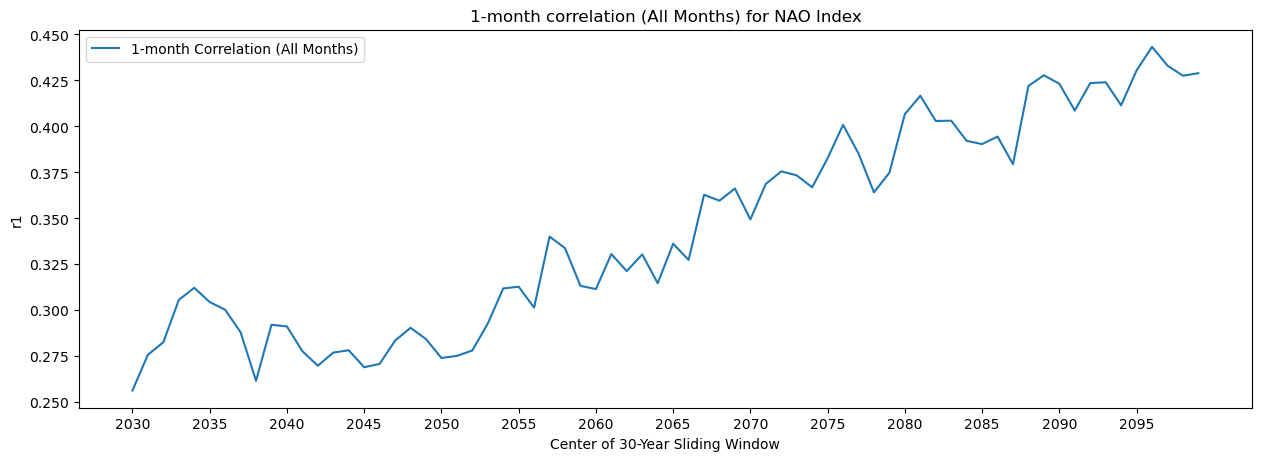

In [23]:
# Visualize it

# Initialize plot
fig,ax = plt.subplots(1,1,constrained_layout=True,figsize=(12.5,4.5))

# Plot value
ax.plot(years,r1_byperiod,label="1-month Correlation (All Months)")

# Labeling
ax.set_xlabel("Center of %i-Year Sliding Window" % (winlen))
ax.set_ylabel("r1")
ax.set_xticks(years[::5])
ax.legend()
ax.set_title("1-month correlation (All Months) for NAO Index")

## II. Calculate 1-month Lag Correlation, DJF Only


Correlation is computed at 1-month lag, restricting to a center "basemonth" (example with basemonth=Jan below):

$\rho_{DJF}(1)$ = $corr(NAO[DJF],NAO[JFM])$

```
Say the timeseries has 100 years... 
  x-axis (base variable)               y-axis (lagged variable)
- D (Years 0 to 99 )           (x) vs. J (Years 1 to 100) (y)
- J (Years 1 to 100)           (x) vs. F (Years 1 to 100) (y)
- F (Years 1 to 100)           (x) vs. M (Years 1 to 100) (y)
```




In [21]:
# Settings
basemonth = 1 # Set the base month (Lag 0)
seasonal  = True # Set to True to use a 3 month window (D) --> (NDJ)
leadlag1  = np.array([-1,0,1]) # Just Compute lead 1 to lag 1 (need to improve func. so that it works with only lags, W.I.P.)

# Compute DJF Correlations by period
r1_djf    = []
for pp in range(nperiods):
    dsper  = nao_byperiod[pp]
    dsbase = dsper
    dslag  = dsper

    corrout = xrcorr_leadlag(dsbase, dslag, basemonth, leadlag1, seasonal=True,debug=False)
    r1_djf.append(corrout.corr.sel(lag=1).data.item())
    

Text(0.5, 1.0, '1-month correlation (All Months) for NAO Index')

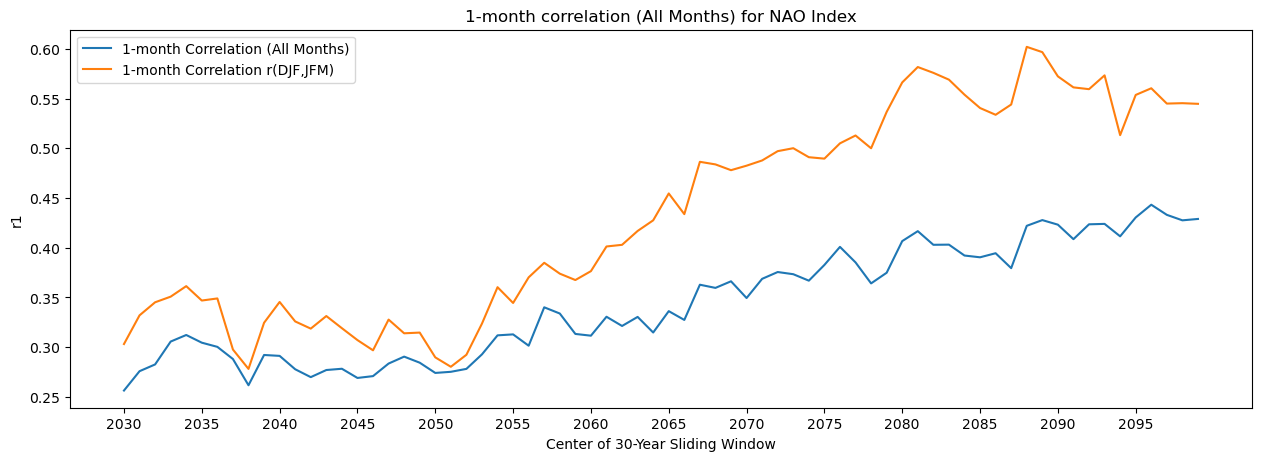

In [24]:
# Visualize it

# Initialize plot
fig,ax = plt.subplots(1,1,constrained_layout=True,figsize=(12.5,4.5))

# Plot All Months (from I)
ax.plot(years,r1_byperiod,label="1-month Correlation (All Months)")

# Plot DJF (from II)
ax.plot(years,r1_djf,label="1-month Correlation r(DJF,JFM)")

# Labeling
ax.set_xlabel("Center of %i-Year Sliding Window" % (winlen))
ax.set_ylabel("r1")
ax.set_xticks(years[::5])
ax.legend()
ax.set_title("1-month correlation (All Months) for NAO Index")

## II. Calculate 1-year Lag Correlation, DJF Only

Correlation is computed at 1-Year lag:

$\rho_{DJF}(1)$ = $corr(NAO[DJF_1],NAO[DJF_2])$

```
Say the timeseries has 100 years... 
  x-axis (base variable)               y-axis (lagged variable)
- D (Years 0 to 98)           (x) vs. D (Years 1 to 99)  (y)
- J (Years 1 to 99)           (x) vs. J (Years 2 to 100) (y)
- F (Years 1 to 99)           (x) vs. F (Years 2 to 100) (y)
```

In [29]:
basemonth  = 1
seasonal   = True
leadlag1yr = np.arange(-1,13,1) #np.array([-1,0,1,12]) #]#np.arange(0,2)

r1_djf_1yr = []
for pp in range(nperiods):
    dsper = nao_byperiod[pp]

    dsbase = dsper
    dslag  = dsper

    
    corrout = xrcorr_leadlag(dsbase, dslag, basemonth, leadlag1yr, seasonal=True,debug=False)
    r1_djf_1yr.append(corrout.corr)

# Get Lag 12 (1-Year Correlation_
r1_yr = [rr.sel(lag=12).data.item() for rr in r1_djf_1yr]

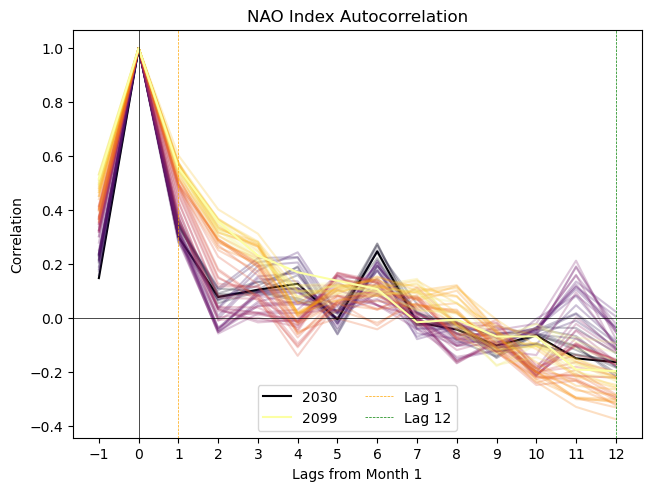

In [51]:
# Also Plot Lead Lag Structure of NAO Index

fig,ax = plt.subplots(1,1,constrained_layout=True)


colors = mpl.cm.inferno(np.linspace(0,1,nperiods))

for pp in range(nperiods):
    if (pp == 0) or (pp == nperiods-1):
        alpha = 1
        lab   = years[pp]
    else:
        alpha = 0.25
        lab   = ""
    
    plotvar = r1_djf_1yr[pp]
    ax.plot(leadlag1yr,plotvar,alpha=alpha,color=colors[pp],label=lab)

ax.axvline([0],c="k",lw=0.5)
ax.axhline([0],c="k",lw=0.5)

ax.axvline([1],c="orange",lw=0.5,ls='dashed',label="Lag 1")
ax.axvline([12],c="green",lw=0.5,ls='dashed',label="Lag 12")

ax.set_xlabel("Lags from Month %0i" % basemonth)
ax.set_xticks(leadlag1yr)
ax.set_ylabel("Correlation")
ax.set_title("NAO Index Autocorrelation")
ax.legend(ncol=2)


Text(0.5, 1.0, 'NAO Persistence at Various Timescales')

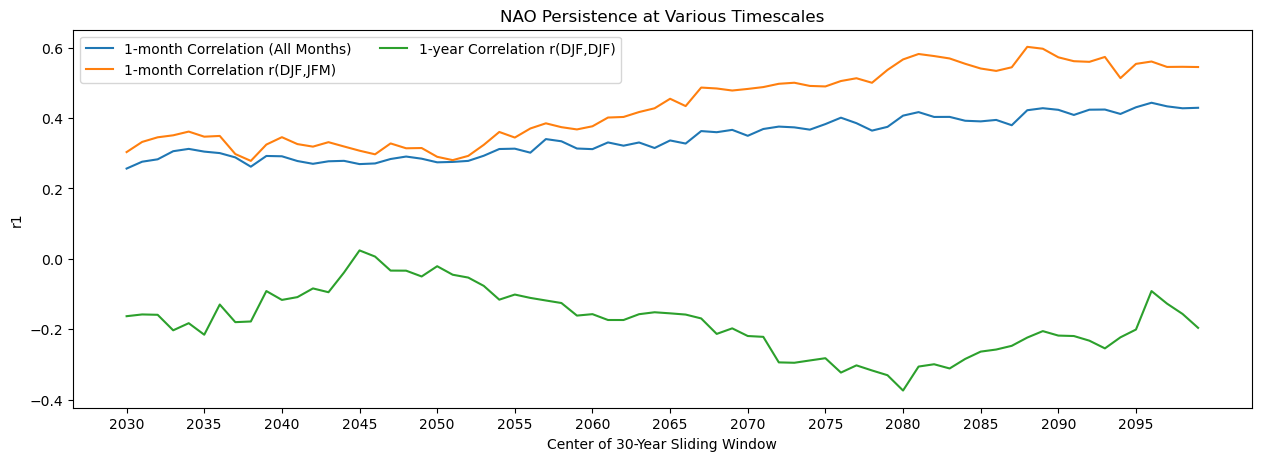

In [69]:
# Visualize it

# Initialize plot
fig,ax = plt.subplots(1,1,constrained_layout=True,figsize=(12.5,4.5))

# Plot All Months (from I)
ax.plot(years,r1_byperiod,label="1-month Correlation (All Months)")

# Plot DJF (from II)
ax.plot(years,r1_djf,label="1-month Correlation r(DJF,JFM)")

# Plot DJF, 1-Year (from III)
ax.plot(years,r1_yr,label="1-year Correlation r(DJF,DJF)")


# Labeling
ax.set_xlabel("Center of %i-Year Sliding Window" % (winlen))
ax.set_ylabel("r1")
ax.set_xticks(years[::5])
ax.legend(ncol=2)

ax.set_title("NAO Persistence at Various Timescales")

# IV. Investigate NAO-ENSO Simultaneous Correlation 

In [58]:
# Split ENSO in periodwise values
ensoid_byperiod,_ = generate_periods(dsenso,winlen)


In [61]:
# Compute Sliding Correlation (All Month and Seasonal)
enso_nao_corr     = []
enso_nao_corr_djf = []

for pp in range(nperiods):
    # All Months
    r1_ensonao = np.corrcoef(ensoid_byperiod[pp],nao_byperiod[pp])[0,1]
    enso_nao_corr.append(r1_ensonao)

    # DJF Only
    ensodjf = selmon_ds(ensoid_byperiod[pp],[12])
    naodjf  = selmon_ds(nao_byperiod[pp],[12])
    r1_ensonao_djf = np.corrcoef(ensodjf,naodjf)[0,1]
    enso_nao_corr_djf.append(r1_ensonao_djf)


Text(0.5, 1.0, 'NAO Persistence and ENSO-NAO Relationship at Various Timescales')

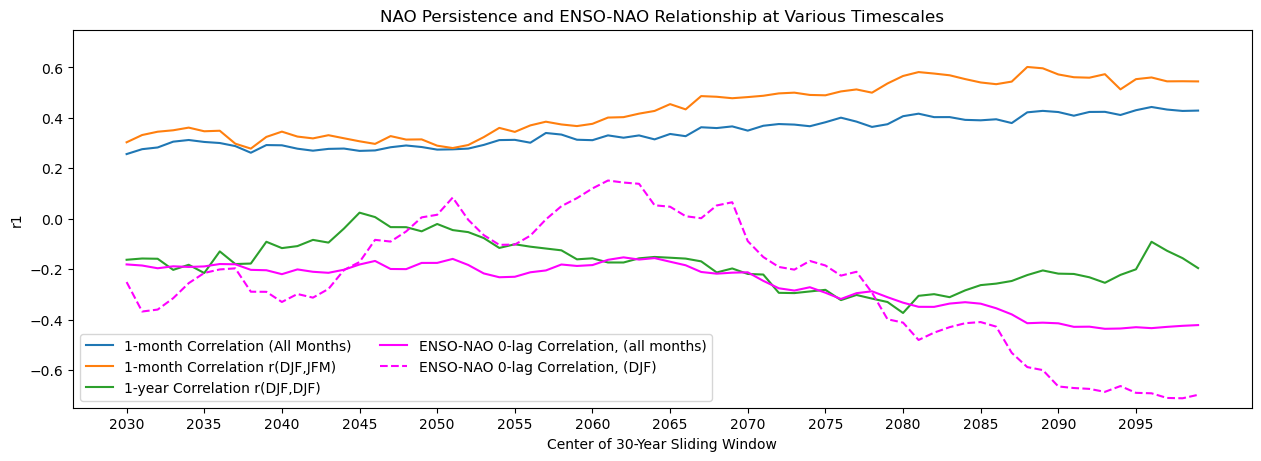

In [68]:
# Visualize it

# Initialize plot
fig,ax = plt.subplots(1,1,constrained_layout=True,figsize=(12.5,4.5))

# Plot All Months (from I)
ax.plot(years,r1_byperiod,label="1-month Correlation (All Months)")

# Plot DJF (from II)
ax.plot(years,r1_djf,label="1-month Correlation r(DJF,JFM)")

# Plot DJF, 1-Year (from III)
ax.plot(years,r1_yr,label="1-year Correlation r(DJF,DJF)")

# Plot Simultaneous ENSO-NAO Correlation (from IV)
ax.plot(years,enso_nao_corr,label="ENSO-NAO 0-lag Correlation, (all months)",c='magenta')
ax.plot(years,enso_nao_corr_djf,label="ENSO-NAO 0-lag Correlation, (DJF)",ls='dashed',c='magenta')

ax.set_ylim([-.75,0.75])

# Labeling
ax.set_xlabel("Center of %i-Year Sliding Window" % (winlen))
ax.set_ylabel("r1")
ax.set_xticks(years[::5])
ax.legend(ncol=2)

ax.set_title("NAO Persistence and ENSO-NAO Relationship at Various Timescales")